In [1]:
import pandas as pd
df = pd.read_csv("Desktop/predict.csv")


In [2]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [17]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [3]:
df = df.dropna(subset=['CustomerID'])


In [4]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


In [5]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]


In [6]:
# Create TotalAmount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [7]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [8]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [24]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


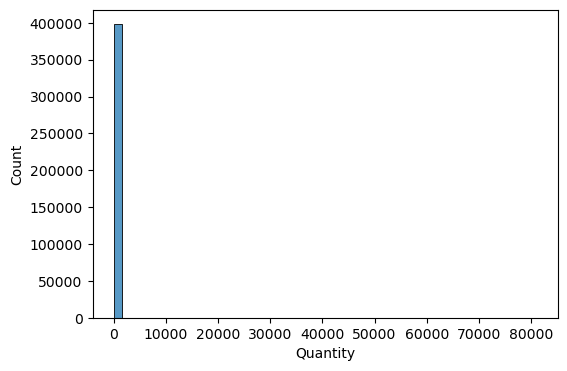

In [41]:

plt.figure(figsize=(6,4))
sns.histplot(df['Quantity'], bins=50)
plt.show()


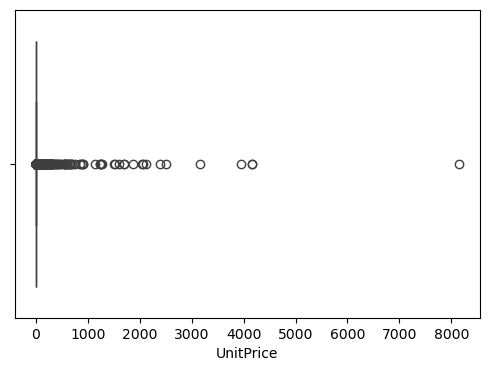

In [42]:

plt.figure(figsize=(6,4))
sns.boxplot(x=df['UnitPrice'])
plt.show()


In [43]:

top_customers = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)
top_customers


CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalAmount, dtype: float64

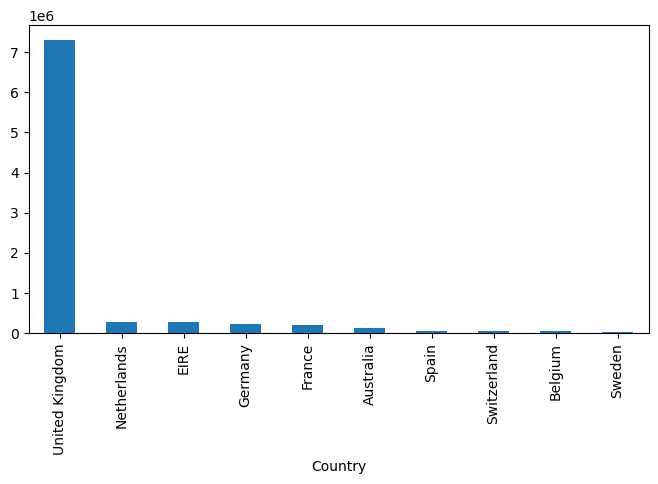

In [44]:

country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
country_sales.plot(kind='bar', figsize=(8,4))
plt.show()


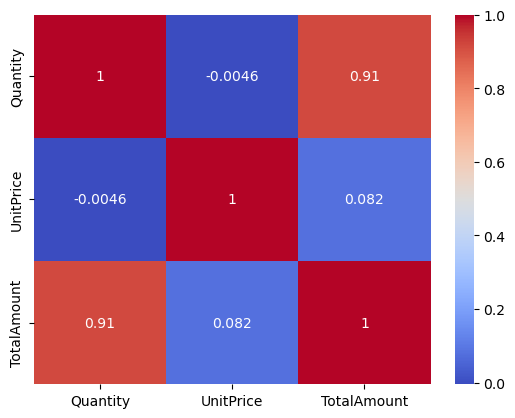

In [45]:

sns.heatmap(df[['Quantity','UnitPrice','TotalAmount']].corr(), annot=True, cmap='coolwarm')
plt.show()


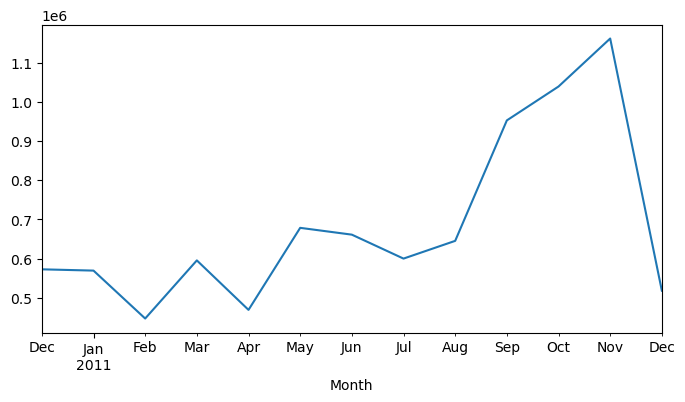

In [46]:

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalAmount'].sum()
monthly_sales.plot(figsize=(8,4))
plt.show()


In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [48]:
customer_df = df.groupby('CustomerID').agg({
    'Quantity': 'sum',
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
}).reset_index()

customer_df.columns = ['CustomerID', 'TotalQuantity', 'PurchaseFrequency', 'TotalSpent']
customer_df.head()


,CustomerID,TotalQuantity,PurchaseFrequency,TotalSpent
0,12346.0,74215,1,77183.60
1,12347.0,2458,182,4310.00
2,12348.0,2341,31,1797.24
3,12349.0,631,73,1757.55
4,12350.0,197,17,334.40


In [49]:
X = customer_df[['TotalQuantity', 'PurchaseFrequency', 'TotalSpent']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


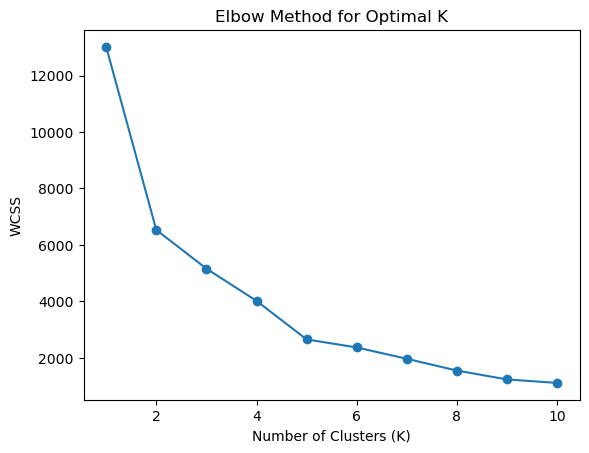

In [50]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


In [75]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df['Class_Label'] = kmeans.fit_predict(X_scaled)

customer_df.head()


,CustomerID,TotalQuantity,PurchaseFrequency,TotalSpent,Class_Label
0,12346.0,74215,1,77183.60,2
1,12347.0,2458,182,4310.00,0
2,12348.0,2341,31,1797.24,0
3,12349.0,631,73,1757.55,0
4,12350.0,197,17,334.40,0


In [76]:
customer_df.groupby('Class_Label').mean()


,CustomerID,TotalQuantity,PurchaseFrequency,TotalSpent
Class_Label,,,,
0,15301.41028,937.420468,83.146562,1601.825493
1,16661.00000,103007.250000,711.750000,225721.652500
2,14649.00000,47137.600000,2395.133333,72682.466000


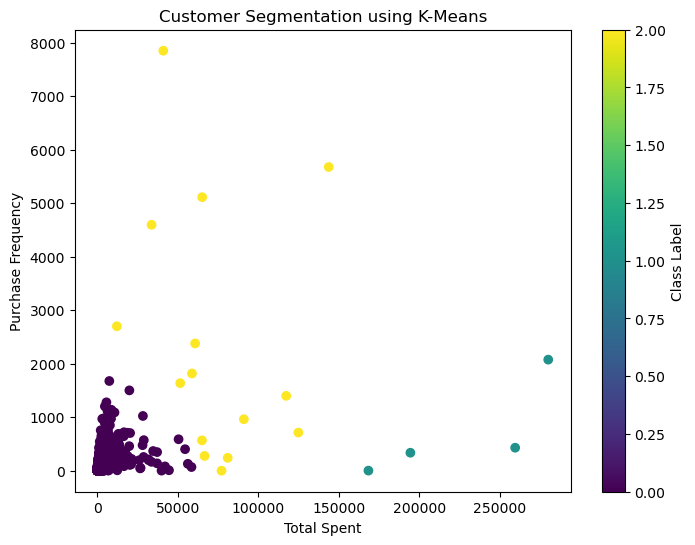

In [77]:
plt.figure(figsize=(8,6))
plt.scatter(customer_df['TotalSpent'], customer_df['PurchaseFrequency'],
            c=customer_df['Class_Label'], cmap='viridis')
plt.xlabel("Total Spent")
plt.ylabel("Purchase Frequency")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label='Class Label')
plt.show()


In [78]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',                                    # Frequency
    'TotalAmount': 'sum'                                     # Monetary
}).reset_index()

rfm_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm_df.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,182,4310.00
2,12348.0,75,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,310,17,334.40


In [79]:
final_df = customer_df.merge(rfm_df, on='CustomerID')
final_df.head()


,CustomerID,TotalQuantity,PurchaseFrequency,TotalSpent,Class_Label,Recency,Frequency,Monetary
0,12346.0,74215,1,77183.60,2,326,1,77183.60
1,12347.0,2458,182,4310.00,0,2,182,4310.00
2,12348.0,2341,31,1797.24,0,75,31,1797.24
3,12349.0,631,73,1757.55,0,19,73,1757.55
4,12350.0,197,17,334.40,0,310,17,334.40


In [80]:
X_generalized = final_df[
    ['TotalQuantity', 'PurchaseFrequency', 'TotalSpent',
     'Recency', 'Frequency', 'Monetary']
]


In [81]:
scaler = StandardScaler()
X_generalized_scaled = scaler.fit_transform(X_generalized)


In [95]:
kmeans_general = KMeans(n_clusters=3, random_state=42)
final_df['Generalized_Class_Label'] = kmeans_general.fit_predict(X_generalized_scaled)

final_df.head()


,CustomerID,TotalQuantity,PurchaseFrequency,TotalSpent,Class_Label,Recency,Frequency,Monetary,Generalized_Class_Label,Cluster_Name
0,12346.0,74215,1,77183.60,2,326,1,77183.60,2,Loyal High-Spending Customers
1,12347.0,2458,182,4310.00,0,2,182,4310.00,0,Low Value / Inactive Customers
2,12348.0,2341,31,1797.24,0,75,31,1797.24,0,Low Value / Inactive Customers
3,12349.0,631,73,1757.55,0,19,73,1757.55,0,Low Value / Inactive Customers
4,12350.0,197,17,334.40,0,310,17,334.40,0,Regular Customers


In [97]:
final_df.groupby('Generalized_Class_Label').agg({
    'TotalQuantity': 'mean',
    'PurchaseFrequency': 'mean',
    'TotalSpent': 'mean',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})





,TotalQuantity,PurchaseFrequency,TotalSpent,Recency,Frequency,Monetary
Generalized_Class_Label,,,,,,
0,937.420468,83.146562,1601.825493,92.840935,83.146562,1601.825493
1,103007.250000,711.750000,225721.652500,3.000000,711.750000,225721.652500
2,47137.600000,2395.133333,72682.466000,28.733333,2395.133333,72682.466000


In [99]:
cluster_names = {
    0: "Low Value / Inactive",
    1: "Potential Customers",
    2: "Loyal High-Value",
    3: "Regular Customers"
}

final_df['Cluster_Name'] = final_df['Generalized_Class_Label'].map(cluster_names)


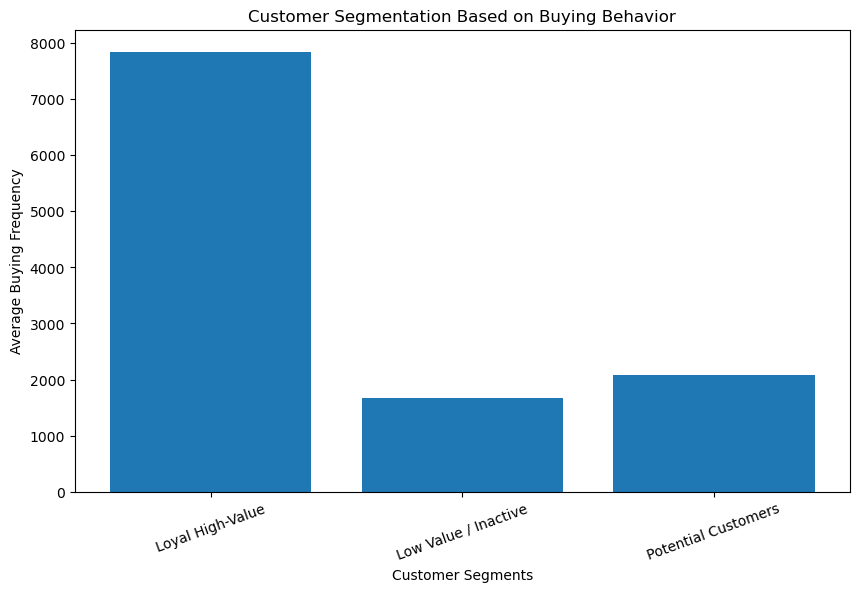

In [104]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

plt.bar(final_df['Cluster_Name'],
        final_df['PurchaseFrequency'])

plt.xlabel("Customer Segments")
plt.ylabel("Average Buying Frequency")
plt.title("Customer Segmentation Based on Buying Behavior")
plt.xticks(rotation=20)

plt.show()


In [101]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_generalized_scaled,
                             final_df['Generalized_Class_Label'])

sil_score


np.float64(0.9297214107501836)

In [102]:
print(f"Silhouette Score for Generalized K-Means Clustering: {sil_score:.3f}")


Silhouette Score for Generalized K-Means Clustering: 0.930
